In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os,sys
import warnings

In [2]:
PROJECT_ROOT = "/home/hushiqi/work/xrs_ana"
SCAN_NAME = "Ho"
DATA_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "data", SCAN_NAME)
RESULT_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "result")
RESULT_DIR = os.path.join(RESULT_PATH, SCAN_NAME)
SQW_PATH = os.path.join(RESULT_DIR, "result.dat")
os.makedirs(RESULT_DIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-xrsana")
warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, PROJECT_ROOT)

from xrsana import xrs_extraction, xrs_read

Loading HEPS ID33 reduced data : /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho
Reading HEPS ID33 NIXS scan:  /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho/Ho_Comptonscan_crystaldivided_all_data.txt
HEPS ID33 reduced data loaded: /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho/Ho_Comptonscan_crystaldivided_all_data.txt

Reader summary
scan_name       : Ho_Comptonscan_crystaldivided
E0 (keV)        : 9.682386649035953
q average       : 6.87230288981313
tth (deg)       : [180.0, 180.0, 180.0, 163.84738382892206, 165.33369125766225, 163.84738382892206, 153.5988275163505, 154.4366300264693, 153.5988275163505, 144.90151250453545, 145.48607644235628, 144.90151250453545, 136.8082090478226, 137.24145036319194, 60.25868267499781, 67.65024685289443, 67.45333530472517, 67.65024685289443, 74.80264414985153, 74.66667895606253, 74.80264414985153, 95.58619648218584, 95.60982215764386, 95.58619648218584, 88.31442845201786, 88.34523871205987, 81.13944673565653, 81.05376610182589, 81.1

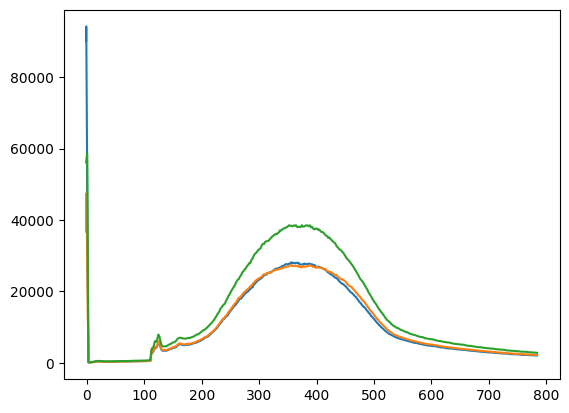

In [3]:
print("Loading HEPS ID33 reduced data :", DATA_PATH)
data = xrs_read.read_heps_id33(DATA_PATH)

print("\nReader summary")
print("scan_name       :", data.scan_name)
print("E0 (keV)        :", data.E0)
print("q average       :", data.q_average)
print("tth (deg)       :", data.tth)
print("eloss shape     :", data.eloss.shape)
print("signals shape   :", data.signals.shape)
print("errors shape    :", data.errors.shape)
print("selected ROIs   :", len(data.selected_rois))
print("analyzer key    :", data.key)
print("\nTesting edge_extraction handoff...")
data_ex = xrs_extraction.edge_extraction(data, ["Ho"], [1.0], {"Ho": ["N5"]})
data_ex.analyzerAverage([0], errorweighing=True)
print("average signal  :", data_ex.avsignals.shape)
print("average error   :", data_ex.averrors.shape)
print("average q head  :", data_ex.avqvals[:5])

plt.plot(data.eloss,data.signals[:,[0,1,2]]) #interactive plot window to look at each analyser output 
plt.show()

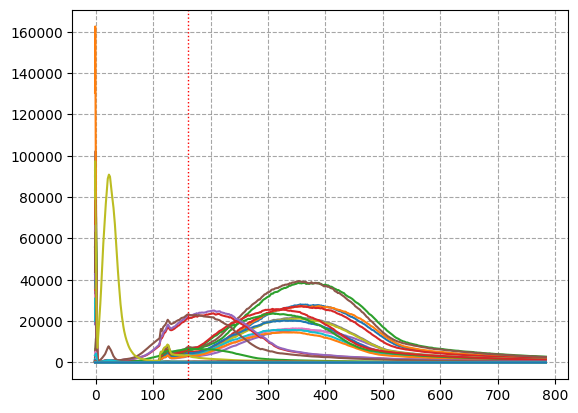

In [4]:
plt.plot(data.eloss, data.signals)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.show()

The fit parameters are:  [4.31633856e+02 4.11705092e+00 3.23720730e+00 2.55804204e+00
 0.00000000e+00 3.08607822e-07 9.99709838e-01]


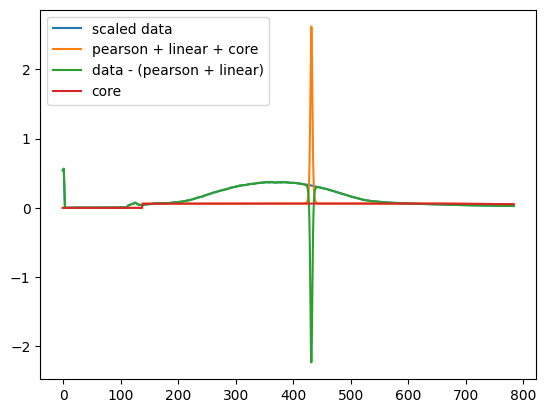

In [5]:
data_ex = xrs_extraction.edge_extraction(data,['Sm'],[1.0],{'Sm':['N4','N5']})
data_ex.analyzerAverage([2],errorweighing=True)
data_ex.removeCorePearsonAv('Sm','N4',[110,120],[140,180],weights=[1,1])

In [21]:
data_ex.save_average_Sqw(SQW_PATH, emin=140,emax=180)
data_ex.sqwav

array([0.04625661, 0.04855233, 0.04620273, 0.04684877, 0.04863398,
       0.0474838 , 0.04678944, 0.04639591, 0.04625051, 0.04689552,
       0.04764422, 0.04704995, 0.0462719 , 0.04550385, 0.04535186,
       0.04625291, 0.04737721, 0.04671586, 0.04655751, 0.04694312,
       0.04945272, 0.05012264, 0.0492065 , 0.04603531, 0.04492832,
       0.04512574, 0.04707513, 0.04679224, 0.04500191, 0.04223983,
       0.04415047, 0.04756081, 0.04578565, 0.04873249, 0.05276188,
       0.05018882, 0.04858512, 0.04745899, 0.0463876 , 0.04635275,
       0.04683368, 0.04727971, 0.04866637, 0.04989079, 0.04898527,
       0.04892606, 0.04917484, 0.04926317, 0.04733881, 0.04573809,
       0.04957813, 0.04919364, 0.04685514, 0.04479106, 0.04653729,
       0.04934715, 0.04919244, 0.04782071, 0.04647047, 0.04713612,
       0.04845734, 0.05039665, 0.05396286, 0.0521964 , 0.04868512,
       0.04784551, 0.04717759, 0.04665567, 0.04644133, 0.04720056,
       0.04833433, 0.04941067, 0.04866627, 0.04736522, 0.04628

In [6]:
saved_sqw = np.genfromtxt(SQW_PATH, usecols=(0,1))
plt.plot(saved_sqw[:,0], saved_sqw[:,1])
#plt.yscale('log')
plt.grid()
plt.show()

FileNotFoundError: /home/hushiqi/work/xrs_ana/ex_space/analysis/result/Ho/result.dat not found.